In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from seaborn import color_palette
import h5py, matplotlib, os

from msi import emulator, abc
from msfm.utils import prior, files, parameters

from emcee import EnsembleSampler
from trianglechain import TriangleChain

# setup
matplotlib.rcParams.update({'font.size': 14})
np.set_printoptions(precision=3)
print(tf.config.list_physical_devices())
conf = files.load_config()

23-06-26 06:12:02   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 
23-06-26 06:12:02    scales.py INF   Setting up healpy to run on 256 CPUs 
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# load the summaries

In [2]:
def load_preds(base_dir, model_dir, n_steps=None, file_label=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    elif file_label is None:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}_{file_label}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_train_preds = f["fiducial/train/pred"][:]
        fidu_vali_preds = f["fiducial/vali/pred"][:]

        print(f"fidu_train_preds =   {fidu_train_preds.shape}")
        print(f"fidu_vali_preds =    {fidu_vali_preds.shape}")

        # grid
        grid_preds = f["grid/pred"][:]
        grid_cosmos = f["grid/cosmo"][:]
        print(f"grid_preds.shape =  {grid_preds.shape}")
        print(f"grid_cosmos.shape = {grid_cosmos.shape}")
        
        print(f"\nsingle grid pred example = {grid_preds[0,0]}")
        
        print(f["fiducial/vali/i_example"][:])

    return fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos

# def load_preds(base_dir, model_dir, n_steps=None):
#     out_dir = os.path.join(base_dir, model_dir)
    
#     if n_steps is None:
#         preds_file = os.path.join(out_dir, f"preds.h5")
#     else:
#         preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

#     with h5py.File(preds_file, "r") as f:
#         # fiducial
#         fidu_preds = f["fiducial/preds"][:]
#         print(f"fidu_preds =        {fidu_preds.shape}")

#         # grid
#         grid_preds = f["grid/preds"][:]
#         grid_cosmos = f["grid/cosmos"][:]
#         print(f"grid_preds.shape =  {grid_preds.shape}")
#         print(f"grid_cosmos.shape = {grid_cosmos.shape}")
        
#         print(f"\nsingle grid pred example = {grid_preds[0,0]}")

#     return fidu_preds, grid_preds, grid_cosmos

### individual experiments

In [3]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3/"

In [4]:
# # old, lensing only

# preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

# fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

# # only select unique values of Om and s8
# grid_cosmos = grid_cosmos[:,0,[2,4]]

# print(grid_cosmos.shape)

# params = ["Om", "s8"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$']
# fiducial = {"Om": 0.26, "s8": 0.84}

In [5]:
# # probably overfit
# model_dir = "2023-05-15_07-04-57_resnet_vanilla"

# fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir)

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

In [6]:
# # clustering only, regular evaluation
# model_dir = "2023-05-24_05-18-42_resnet_vanilla"
# n_steps = 20000

# fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

In [7]:
# # clustering only, regular evaluation
# model_dir = "2023-05-24_05-18-42_resnet_vanilla"
# n_steps = 30001

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}
# out_dir = os.path.join(base_dir, model_dir)

# if n_steps is None:
#     preds_file = os.path.join(out_dir, f"preds.h5")
# else:
#     preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

# with h5py.File(preds_file, "r") as f:
#     print(f["fiducial"].keys())
#     # fiducial
#     fidu_preds = f["fiducial/vali/pred"][:]
#     print(f"fidu_preds =        {fidu_preds.shape}")

#     # grid
#     grid_preds = f["grid/pred"][:]
#     grid_cosmos = f["grid/cosmo"][:]
#     print(f"grid_preds.shape =  {grid_preds.shape}")
#     print(f"grid_cosmos.shape = {grid_cosmos.shape}")


In [8]:
# # lensing only, regular evaluation
# model_dir = "2023-05-24_05-26-55_resnet_vanilla"
# n_steps = 15000

# fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# params = ["Om", "s8", "Aia", "n_Aia"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

In [9]:
# # lensing only, regular evaluation, reduced parameters
# model_dir = "2023-05-24_06-39-40_resnet_vanilla"

# n_steps = 20000
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

# fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

# params = ["Om", "s8"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$']
# fiducial = {"Om": 0.26, "s8": 0.84}

In [10]:
# # clustering only, regular evaluation
# model_dir = "2023-05-24_05-18-42_resnet_vanilla"
# n_steps = 30001

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

### with fiducial validation set

In [11]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"
# n_steps = 50000

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# # out_dir = os.path.join(base_dir, model_dir)
# # preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# # with h5py.File(preds_file, "r") as f:
# #     # fiducial
# #     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
# #     print(f["fiducial/vali/i_example"][:])
    
# # print(no_survey_systematics_fidu_vali_preds.shape)

# abc_scale = 2.0

In [12]:
# # clustering only, modified loss
# model_dir = "2023-05-31_05-41-15_resnet_vanilla"
# n_steps = 50000

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

In [13]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# params = ["Om", "s8", "Aia", "n_Aia"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}
# abc_scale = 0.5

In [14]:
# probe combination
model_dir = "2023-05-30_10-56-53_resnet_vanilla"
n_steps = 10000

params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$', r'$b_g$', r'$\eta_{b_g}$']
fiducial = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5, "bg": 1.5, "n_bg": 0.5}

fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)
abc_scale = 2.0

fidu_train_preds =   (750, 6)
fidu_vali_preds =    (50, 6)
grid_preds.shape =  (2499, 16, 6)
grid_cosmos.shape = (2499, 6)

single grid pred example = [ 0.019  0.068 -0.494  0.292  0.406 -0.653]
[264 243 760 718 564 200 369 470 393 244 389  11 143  27 319 783 137 489
 515 366  59 355 161 141 337 402 543 752 674 645 122  72 455 289 505 350
 655 733 294 112 727 665 325 427 607 354 444 661 425 651]


### fixed loss

In [15]:
# # clustering only, modified loss
# model_dir = "2023-06-02_05-33-34_resnet_vanilla"
# n_steps = 30000

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)
# abc_scale = 2.0

In [16]:
# # lensing only
# model_dir = "2023-06-02_05-32-45_resnet_vanilla"
# n_steps = 30002

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# params = ["Om", "s8", "Aia", "n_Aia"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}
# abc_scale = 0.5

distributed - local comparison

In [17]:
# # clustering only, modified loss, distributed
# model_dir = "2023-06-06_06-22-31_resnet_vanilla"
# n_steps = 10000

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)
# abc_scale = 2.0

In [18]:
# # clustering only, modified loss, local
# model_dir = "2023-06-07_01-45-13_resnet_vanilla"
# n_steps = 10001

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)
# abc_scale = 2.0

### plot the summaries

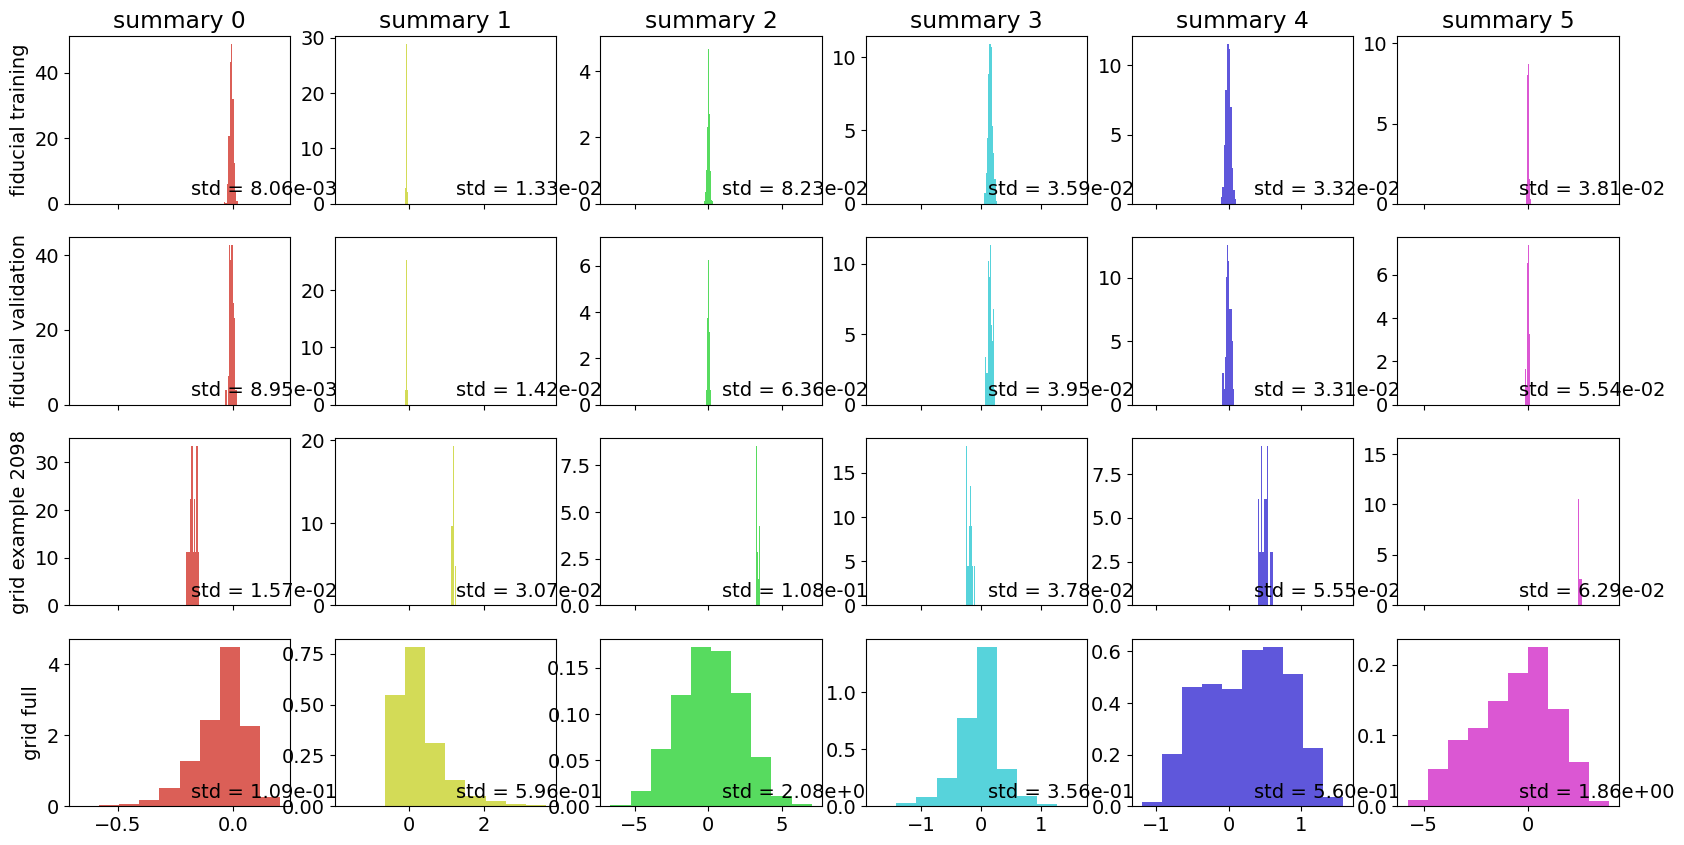

In [19]:
colors = color_palette("hls", n_params)
n_bins = 10

fig, ax = plt.subplots(nrows=4, ncols=n_params, figsize=(20,10), sharex="col")

# fiducial training
ax[0,0].set(ylabel="fiducial training")
for i in range(n_params):
    preds = fidu_train_preds[:,i]
    
    ax[0,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[0,i].set(title=f"summary {i}")
    ax[0,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[0,i].transAxes)

# fiducial validation
ax[1,0].set(ylabel="fiducial validation")
for i in range(n_params):
    preds = fidu_vali_preds[:,i]
    
    ax[1,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[1,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[1,i].transAxes)

# grid example
i_example = np.random.randint(grid_preds.shape[0])

ax[2,0].set(ylabel=f"grid example {i_example}")
for i in range(n_params):
    preds = grid_preds[i_example,:,i]
    
    ax[2,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[2,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[2,i].transAxes)

# grid total
ax[3,0].set(ylabel="grid full")
for i in range(n_params):
    preds = grid_preds[:,:,i].flatten()
    
    ax[3,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[3,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[3,i].transAxes)


# Estimate the ABC posterior

### define the observation

In [20]:
obs_pred = np.median(fidu_vali_preds, axis=0)

In [21]:
# # obs_pred = fidu_vali_preds[0]
# obs_pred = no_survey_systematics_fidu_vali_preds[0]

# print(fidu_vali_preds[0])
# print(no_survey_systematics_fidu_vali_preds[0])

### estimate the Fisher matrix

In [22]:
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # PCA
# pca = PCA(whiten=False)
# pca.fit(fidu_preds)

# obs_pred = np.squeeze(pca.transform(obs_pred[np.newaxis,:]))
# fidu_preds = pca.transform(fidu_preds)

# original_shape = grid_preds.shape
# grid_preds = grid_preds.reshape(-1, grid_preds.shape[-1])
# grid_preds = pca.transform(grid_preds)
# grid_preds = grid_preds.reshape(original_shape)

# # standard scaler
# scaler = StandardScaler()
# scaler.fit(fidu_preds)

# obs_pred = np.squeeze(scaler.transform(obs_pred[np.newaxis,:]))
# fidu_preds = scaler.transform(fidu_preds)

# original_shape = grid_preds.shape
# grid_preds = grid_preds.reshape(-1, grid_preds.shape[-1])
# grid_preds = scaler.transform(grid_preds)
# grid_preds = grid_preds.reshape(original_shape)

In [23]:
fid_cov = np.cov(fidu_vali_preds, rowvar=False)
fid_inv_cov = np.linalg.inv(fid_cov)

[Text(0.5, 1.0, 'fiducial inverse covariance')]

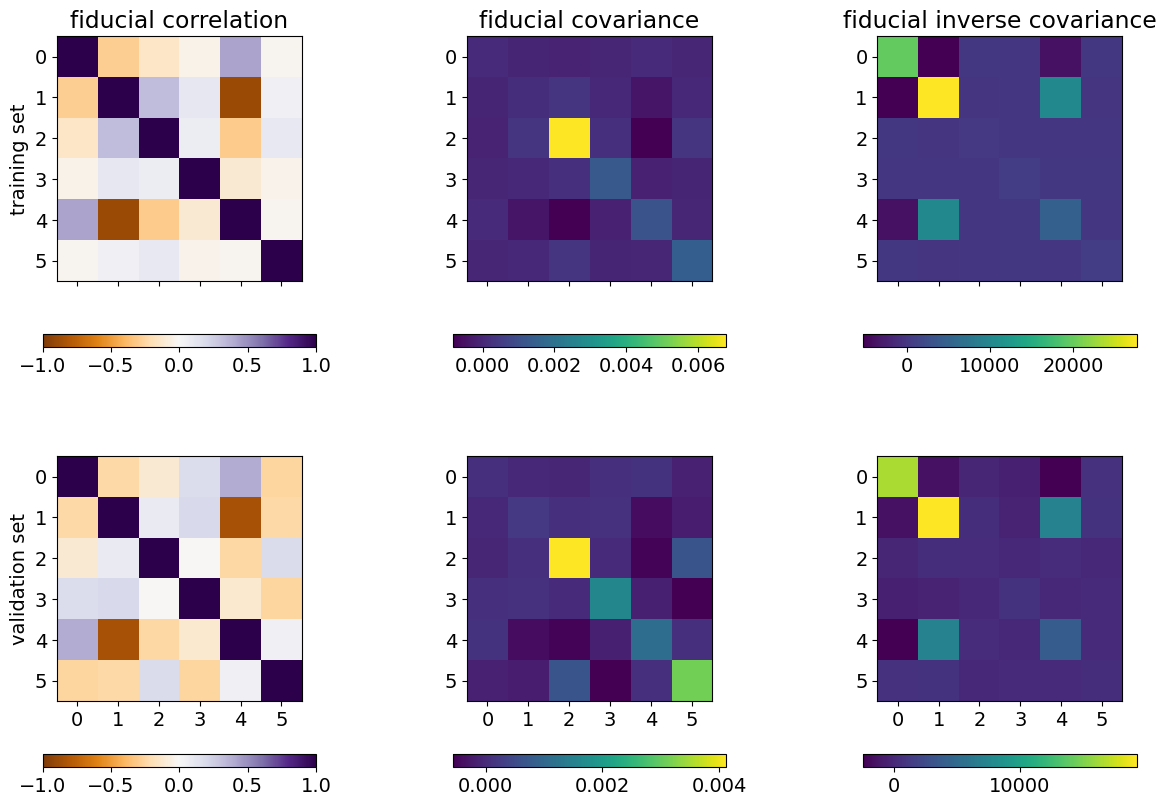

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,10), sharex=True)

preds = [fidu_train_preds, fidu_vali_preds]
labels = ["training set", "validation set"]

for i, (pred, label) in enumerate(zip(preds, labels)):
    # correlation
    correlation = np.corrcoef(pred, rowvar=False)
    im = ax[i,0].imshow(correlation, cmap="PuOr", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax[i,0], orientation="horizontal", shrink=0.8)
    ax[i,0].set(ylabel=label)

    # covariance
    covariance = np.cov(pred, rowvar=False)
    im = ax[i,1].imshow(covariance, cmap="viridis")
    fig.colorbar(im, ax=ax[i,1], orientation="horizontal", shrink=0.8)

    # inverse covariance
    inv_covariance = np.linalg.inv(covariance)
    im = ax[i,2].imshow(inv_covariance, cmap="viridis")
    fig.colorbar(im, ax=ax[i,2], orientation="horizontal", shrink=0.8)

    # cosmetics
    for current_ax in ax[i]:
        current_ax.set_xticks(np.arange(len(params)))
        current_ax.set_xticklabels(np.arange(fid_cov.shape[0]))

        current_ax.set_yticks(np.arange(len(params)))
        current_ax.set_xticklabels(np.arange(fid_cov.shape[0]))

ax[0,0].set(title=f"fiducial correlation")
ax[0,1].set(title=f"fiducial covariance") 
ax[0,2].set(title=f"fiducial inverse covariance")


### ABC posterior

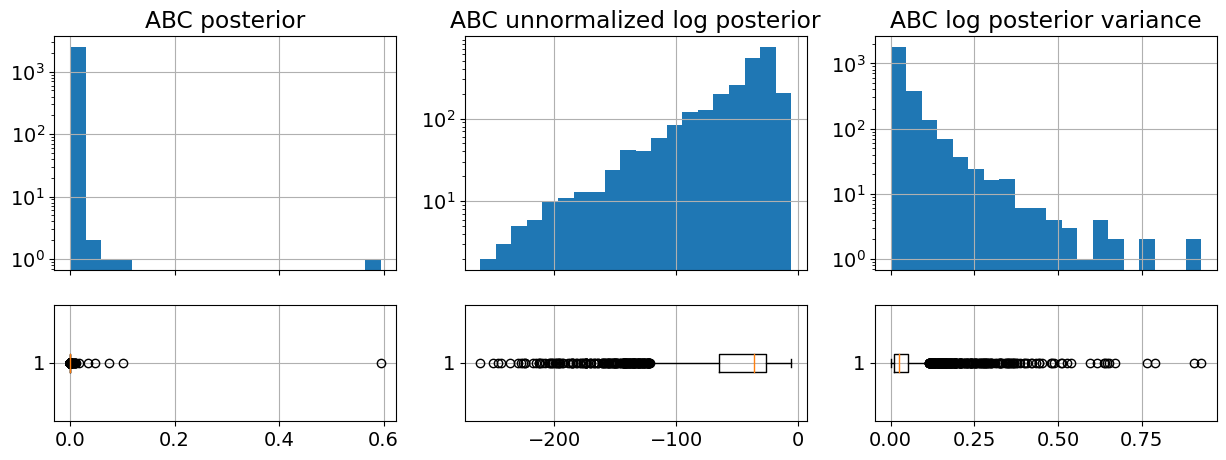

In [25]:
# kernel params
kernel = "sigmoid"

# Estimate the posterior and its uncertainties like in the paper
Y_init, abc_posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=abc_scale, 
    kernel=kernel
)

# check posterior
assert np.isclose(np.sum(abc_posterior), 1.0)

fig, ax = plt.subplots(nrows=2, ncols=3, sharex="col", figsize=(15,5), height_ratios=[2,1])

# posterior
ax[0,0].hist(abc_posterior, log=True, bins=20)
ax[0,0].set(title="ABC posterior")

ax[1,0].boxplot(abc_posterior, vert=False)

# log posterior
ax[0,1].hist(Y_init[:,0], log=True, bins=20)
ax[0,1].set(title="ABC unnormalized log posterior")

ax[1,1].boxplot(Y_init[:,0], vert=False)

# log posterior variance
ax[0,2].hist(Y_init[:,1], log=True, bins=20)
ax[0,2].set(title="ABC log posterior variance")

ax[1,2].boxplot(Y_init[:,1], vert=False)

# cosmetics
for i in range(2):
    for j in range(3):
        ax[i,j].grid(True)

In [26]:
Om = grid_cosmos[:,0]
s8 = grid_cosmos[:,1]

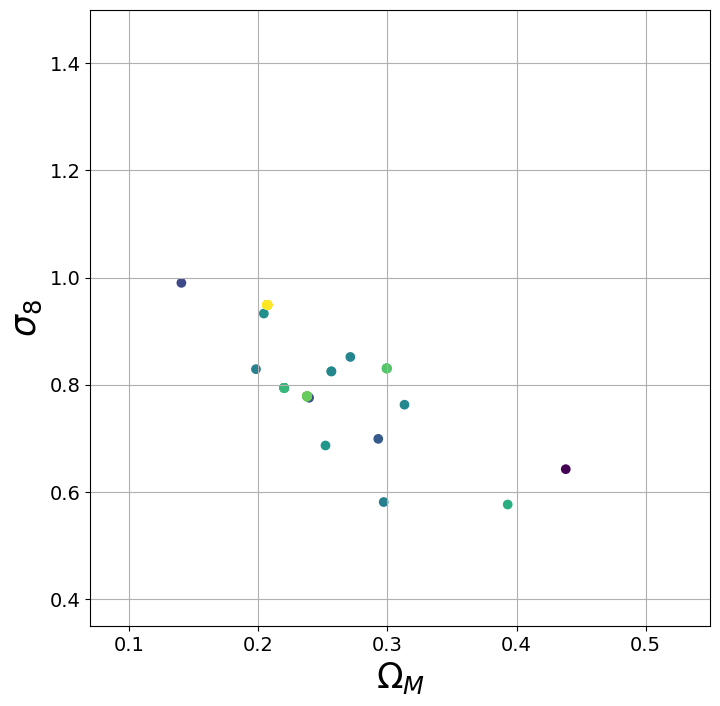

In [27]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 100, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the emulator

In [28]:
X_init = grid_cosmos

In [29]:
# n_grid_points = 500
# indices = np.random.choice(np.arange(X_init.shape[0]), n_grid_points, replace=False)

# X_init = X_init[indices]
# Y_init = Y_init[indices]

# Om = Om[indices]
# s8 = s8[indices]

In [30]:
emu = emulator.VGP_Emu(
    X_init=X_init, 
    Y_init=Y_init, 
    kernel_type="exponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (6,)            │ float64 │ [1., 1., 1....   │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

In [31]:
emu.repeated_fit(n_steps=1000, n_restarts=1, full_restart=True)

100%|████████████████████████████|   | 1000/1000 [01:47<00:00,  9.31it/s, loss_val=1.02e+3] fit the GP
23-06-26 06:14:03  emulator.py INF   Training run 0: loss = 1019.2903802700084 
23-06-26 06:14:03  emulator.py INF   Training run 0 was best, setting those parameters 
╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤═══════════════════════════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value                                 │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪═══════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 0.75053                               │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼─────────────────────────

### plot the $\Omega_M - \sigma_8$ plane

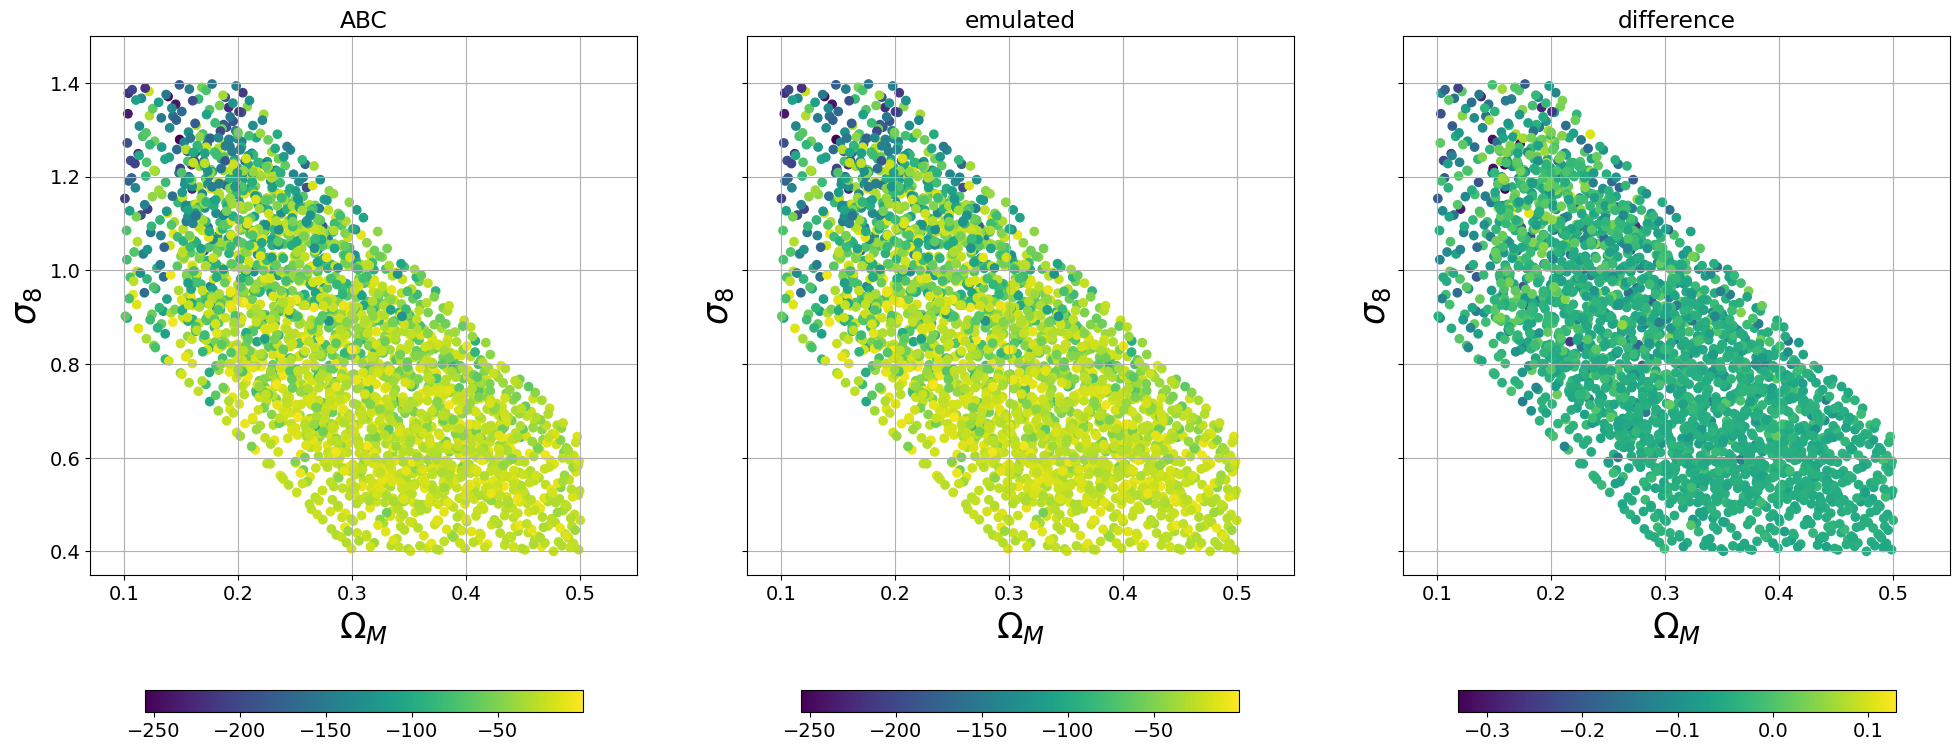

In [32]:
def normalize_Y(Y):
    normalized_prob = Y
    normalized_prob -= np.max(normalized_prob)
    normalized_prob = np.exp(normalized_prob)
    normalized_prob /= np.sum(normalized_prob) 
    
    return normalized_prob

fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
original = np.log(normalize_Y(Y_init[:,0]))
im = ax[0].scatter(Om, s8, c=original)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
emulated = np.squeeze(np.log(normalize_Y(emu(X_init))))
im = ax[1].scatter(Om, s8, c=emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=original - emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)


# Run the MCMC

In [33]:
log_posterior = lambda X: prior.log_posterior(X, emu(X), params=params, conf=conf)

In [34]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
ndim = len(params)
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(nwalkers, ndim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [35]:
# sample burn in
sampler = EnsembleSampler(nwalkers, ndim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_gp_abc.npy"), chain)

100%|██████████| 1000/1000 [01:15<00:00, 13.24it/s]


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

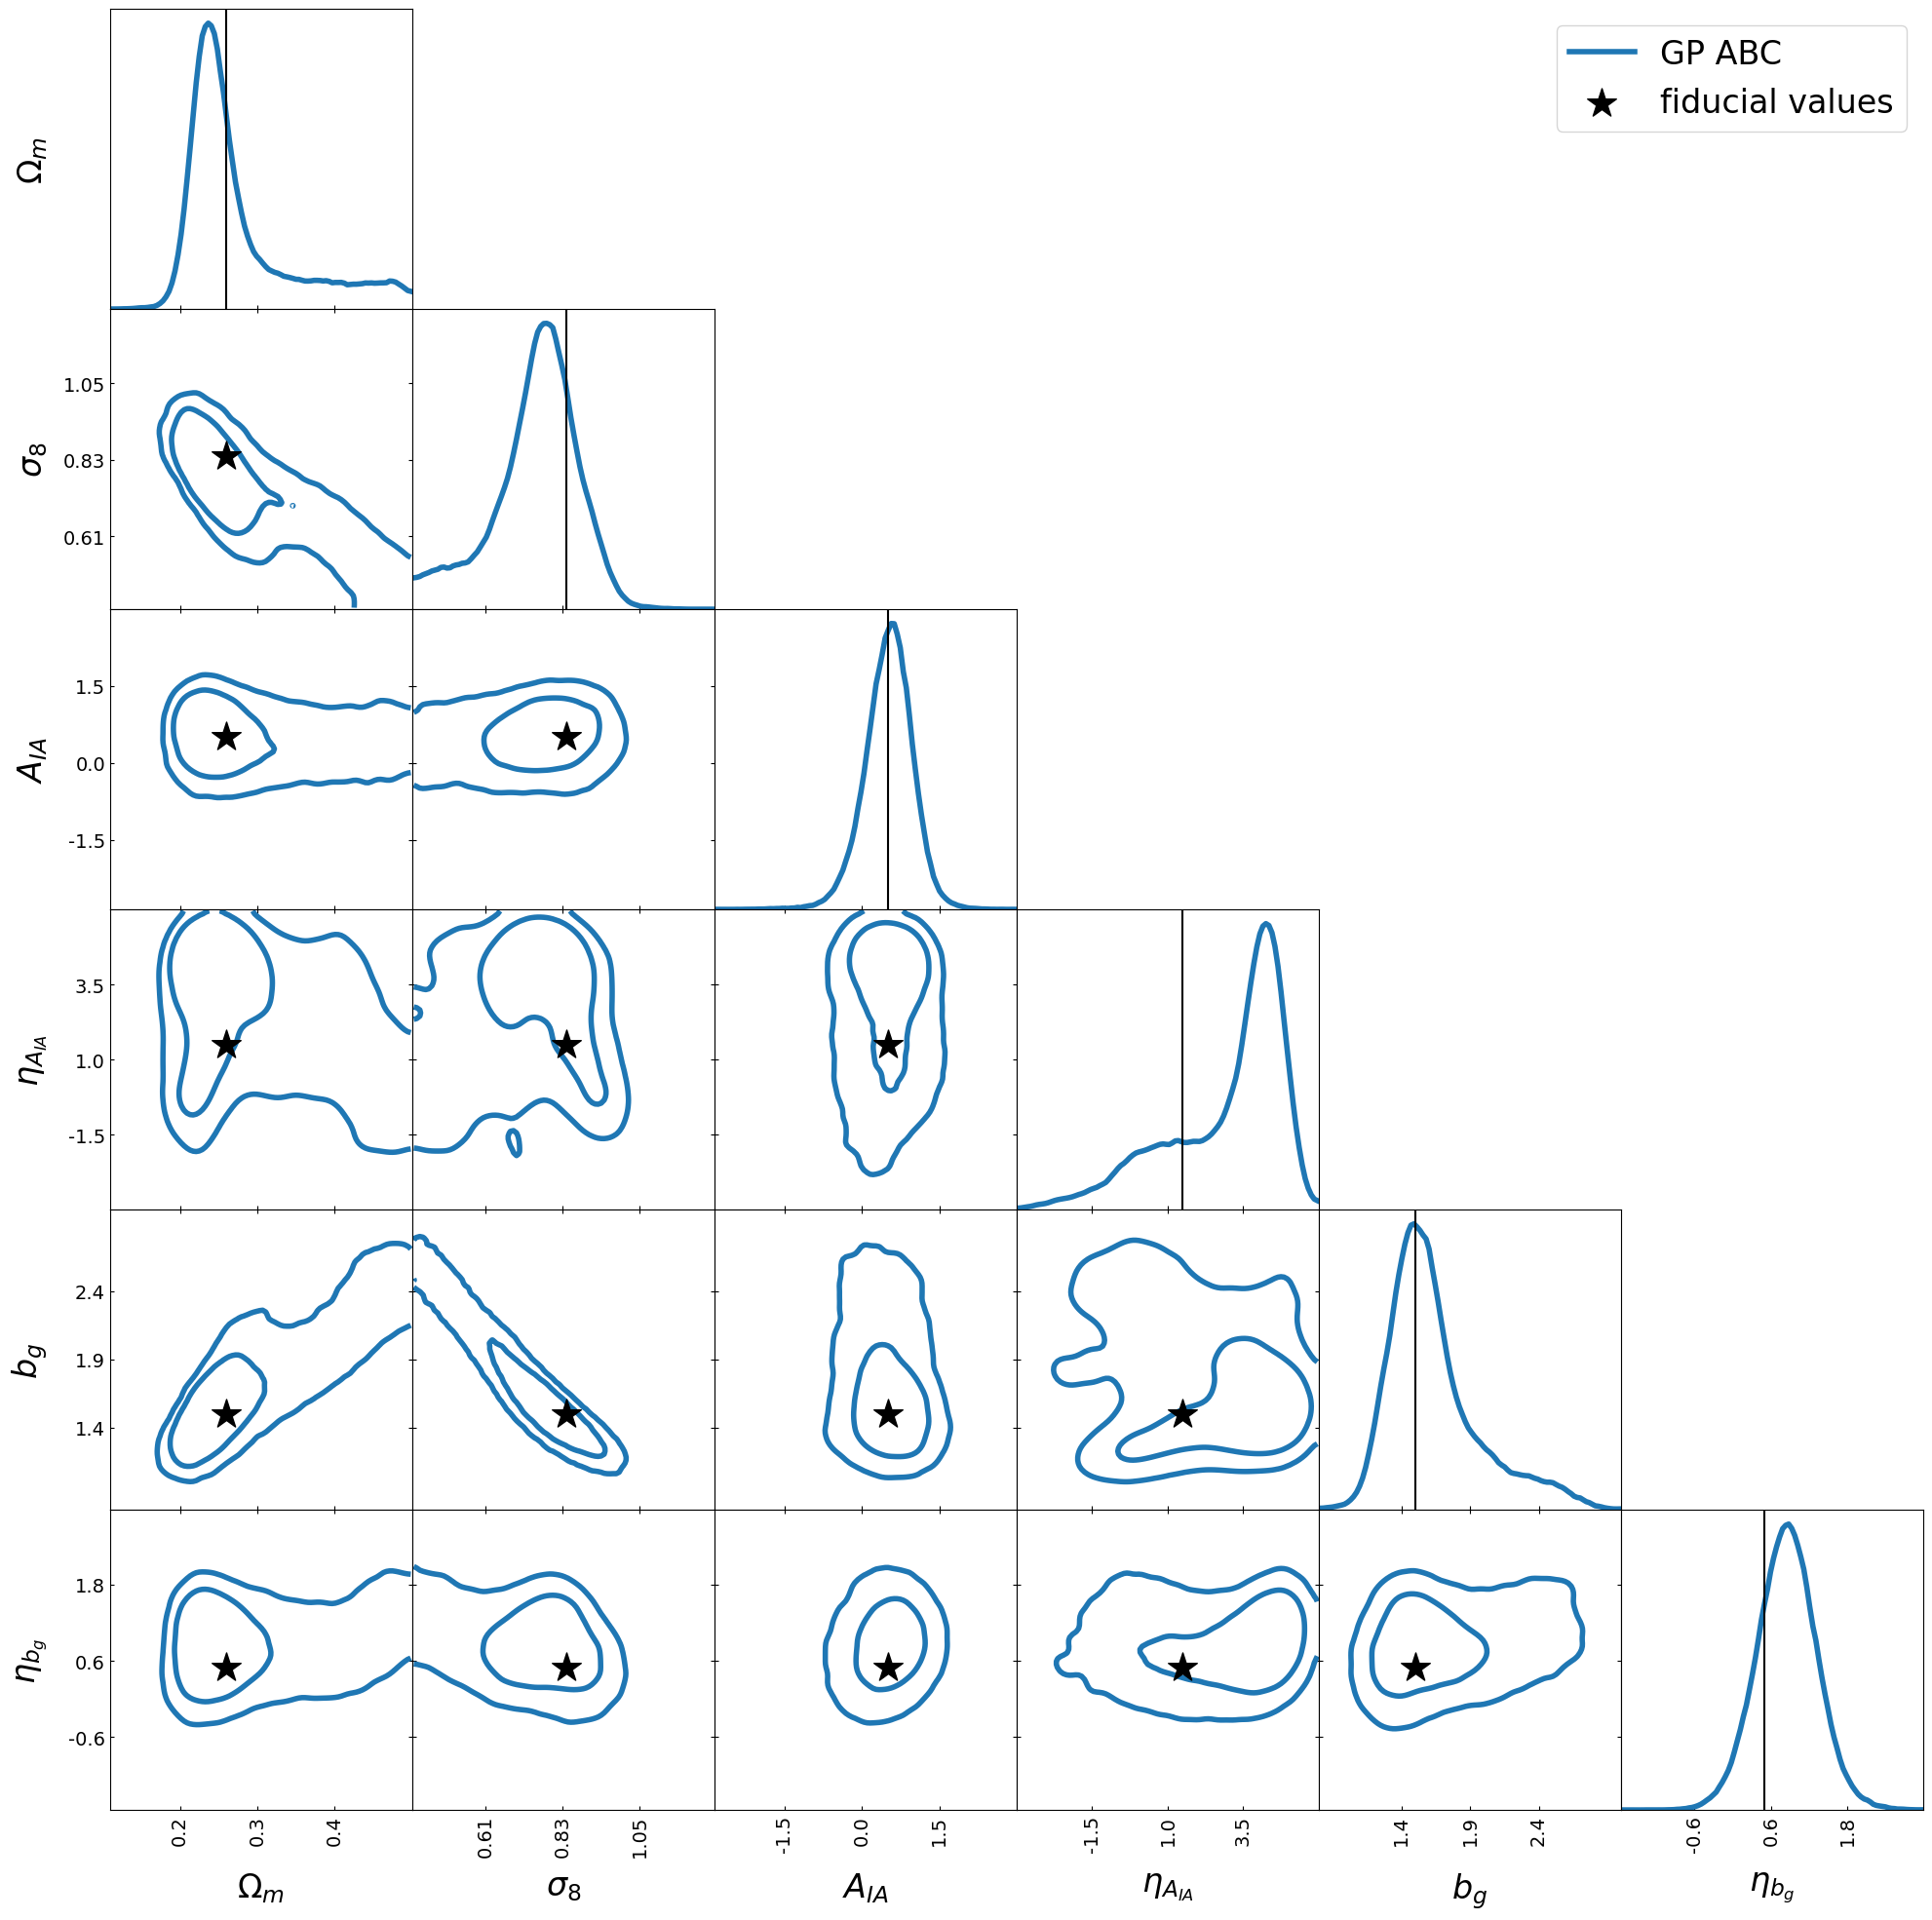

In [36]:
tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})
tri.contour_cl(chain, names=params, label="GP ABC")
tri.scatter(
    fiducial,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_gp_abc.png"), bbox_inches="tight", dpi=300)
# np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}.npy"), chain)

# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_no_survey_systematics.png"), bbox_inches="tight", dpi=300)
# np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_single_obs_no_survey_systematics.npy"), chain)

# custom plot

In [37]:
# standard_chain = np.load("/pscratch/sd/a/athomsen/run_files/v3/2023-05-30_01-48-23_resnet_vanilla/chain_50000_single_obs.npy")
# no_sys_chain = np.load("/pscratch/sd/a/athomsen/run_files/v3/2023-05-30_01-48-23_resnet_vanilla/chain_50000_single_obs_no_survey_systematics.npy")

# tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})
# tri.contour_cl(standard_chain, names=params, label="with survey systematics", color="blue")
# tri.contour_cl(no_sys_chain, names=params, label="without survey systematics", color="orange")
# tri.scatter(
#     fiducial,
#     label="fiducial values",
#     plot_histograms_1D=False,
#     color="k",
#     show_legend=True,
#     scatter_vline_1D=True,
# )
